# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [ ]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 40.8 MB/s eta 0:00:00


In [ ]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [ ]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Tokenize the text
    tokens = word_tokenize(text)

    # Step 3: Remove punctuation tokens
    tokens = [token for token in tokens if token not in string.punctuation]

    # Step 4: Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]

    # Step 5: Lemmatize remaining tokens
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Step 6: Join back into a single cleaned string
    cleaned_text = ' '.join(tokens)
    return cleaned_text


# Test the function on the first review
print("Testing preprocess_text() function:")
print(f"Original: {raw_reviews[0]}")
print(f"Cleaned: {preprocess_text(raw_reviews[0])}")


Testing preprocess_text() function:
Original: At McDonald's the food was ok and the service was bad.
Cleaned: mcdonald 's food ok service bad


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [ ]:
# Apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

print("\n=== RAW vs CLEANED REVIEWS ===")
for i, (raw, cleaned) in enumerate(zip(raw_reviews, cleaned_reviews), 1):
    print(f"\n[{i}] RAW: {raw}")
    print(f"[{i}] CLEANED: {cleaned}")



=== RAW vs CLEANED REVIEWS ===

[1] RAW: At McDonald's the food was ok and the service was bad.
[1] CLEANED: mcdonald 's food ok service bad

[2] RAW: I would not recommend this Japanese restaurant to anyone.
[2] CLEANED: would recommend japanese restaurant anyone

[3] RAW: I loved this restaurant when I traveled to Thailand last summer.
[3] CLEANED: loved restaurant traveled thailand last summer

[4] RAW: The menu of Loving has a wide variety of options.
[4] CLEANED: menu loving wide variety option

[5] RAW: The staff was friendly and helpful at Google's employees restaurant.
[5] CLEANED: staff friendly helpful google 's employee restaurant

[6] RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
[6] CLEANED: ambiance bella italia amazing pasta dish delicious

[7] RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
[7] CLEANED: terrible experience pizza hut pizza burnt service slow

[8] RAW: The sushi at Sushi Ex

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [ ]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # Run the spaCy pipeline on the text
    doc = nlp(text)

    # Collect each entity text and its label_
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities


# Test NER on the first review
print("\nTesting perform_ner() function:")
print(f"Text: {raw_reviews[0]}")
print(f"Entities: {perform_ner(raw_reviews[0])}")



Testing perform_ner() function:
Text: At McDonald's the food was ok and the service was bad.
Entities: [('McDonald', 'ORG')]


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [ ]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # Tokenize the text
    tokens = word_tokenize(text)

    # Call nltk.pos_tag on the tokens
    pos_tags = pos_tag(tokens)
    return pos_tags


# Test POS tagging on the first review
print("\nTesting perform_pos_tagging() function:")
print(f"Text: {raw_reviews[0]}")
print(f"POS Tags: {perform_pos_tagging(raw_reviews[0])}")



Testing perform_pos_tagging() function:
Text: At McDonald's the food was ok and the service was bad.
POS Tags: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [ ]:
sample_texts = raw_reviews[:2]
sample_cleaned = cleaned_reviews[:2]

print("\n" + "="*60)
print("NER ON RAW TEXT")
print("="*60)
for i, text in enumerate(sample_texts, 1):
    print(f"\n[{i}] Text: {text}")
    entities = perform_ner(text)
    print(f"    Entities: {entities}")

print("\n" + "="*60)
print("NER ON CLEANED TEXT")
print("="*60)
for i, text in enumerate(sample_cleaned, 1):
    print(f"\n[{i}] Text: {text}")
    entities = perform_ner(text)
    print(f"    Entities: {entities}")

print("\n" + "="*60)
print("POS TAGS ON RAW TEXT")
print("="*60)
for i, text in enumerate(sample_texts, 1):
    print(f"\n[{i}] Text: {text}")
    pos_tags = perform_pos_tagging(text)
    print(f"    POS Tags: {pos_tags}")

print("\n" + "="*60)
print("POS TAGS ON CLEANED TEXT")
print("="*60)
for i, text in enumerate(sample_cleaned, 1):
    print(f"\n[{i}] Text: {text}")
    pos_tags = perform_pos_tagging(text)
    print(f"    POS Tags: {pos_tags}")



NER ON RAW TEXT

[1] Text: At McDonald's the food was ok and the service was bad.
    Entities: [('McDonald', 'ORG')]

[2] Text: I would not recommend this Japanese restaurant to anyone.
    Entities: [('Japanese', 'NORP')]

NER ON CLEANED TEXT

[1] Text: mcdonald 's food ok service bad
    Entities: [("mcdonald 's food ok service", 'ORG')]

[2] Text: would recommend japanese restaurant anyone
    Entities: [('japanese', 'NORP')]

POS TAGS ON RAW TEXT

[1] Text: At McDonald's the food was ok and the service was bad.
    POS Tags: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

[2] Text: I would not recommend this Japanese restaurant to anyone.
    POS Tags: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS T

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [ ]:
from gensim.models import Word2Vec

# Ensure cleaned_reviews is defined from Exercise 1
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

print(f"Number of documents: {len(tokenized_reviews)}")
print(f"Example tokenized review: {tokenized_reviews[0]}")

# Train the Word2Vec model
# Parameters:
# - vector_size: dimension of word vectors (100)
# - window: context window size (5)
# - sg: training algorithm (0 = CBOW, 1 = Skip-gram)
# - min_count: minimum word frequency (1)
# - workers: number of threads (4)
# - epochs: number of training iterations (10)
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    sg=1,
    min_count=1,
    workers=4,
    epochs=10
)

print("\nWord2Vec model trained successfully!")
w2v_model


Number of documents: 10
Example tokenized review: ['mcdonald', "'s", 'food', 'ok', 'service', 'bad']

Word2Vec model trained successfully!


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [ ]:
# Print the vector size and vocabulary size of the model
vector_size = w2v_model.vector_size
vocab_size = len(w2v_model.wv)

print("\n" + "="*60)
print("WORD2VEC MODEL DIMENSIONS")
print("="*60)
print(f"Vector Size: {vector_size}")
print(f"Vocabulary Size: {vocab_size}")
print(f"Total parameters: {vector_size * vocab_size}")

print("\nInterpretation:")
print(f"- Each word in the vocabulary is represented as a {vector_size}-dimensional vector.")
print(f"- The model learned representations for {vocab_size} unique words.")
print(f"- These vectors capture semantic and syntactic relationships between words.")

# Show sample word vectors
print("\nExample word vector for 'restaurant':")
if 'restaurant' in w2v_model.wv:
    print(w2v_model.wv['restaurant'][:10])  # First 10 dimensions
else:
    print("Word 'restaurant' not found in vocabulary")



WORD2VEC MODEL DIMENSIONS
Vector Size: 100
Vocabulary Size: 56
Total parameters: 5600

Interpretation:
- Each word in the vocabulary is represented as a 100-dimensional vector.
- The model learned representations for 56 unique words.
- These vectors capture semantic and syntactic relationships between words.

Example word vector for 'restaurant':
[-0.0005379   0.00023925  0.00510597  0.00901852 -0.00930066 -0.00712257
  0.00646781  0.00897955 -0.00501212 -0.00377144]


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

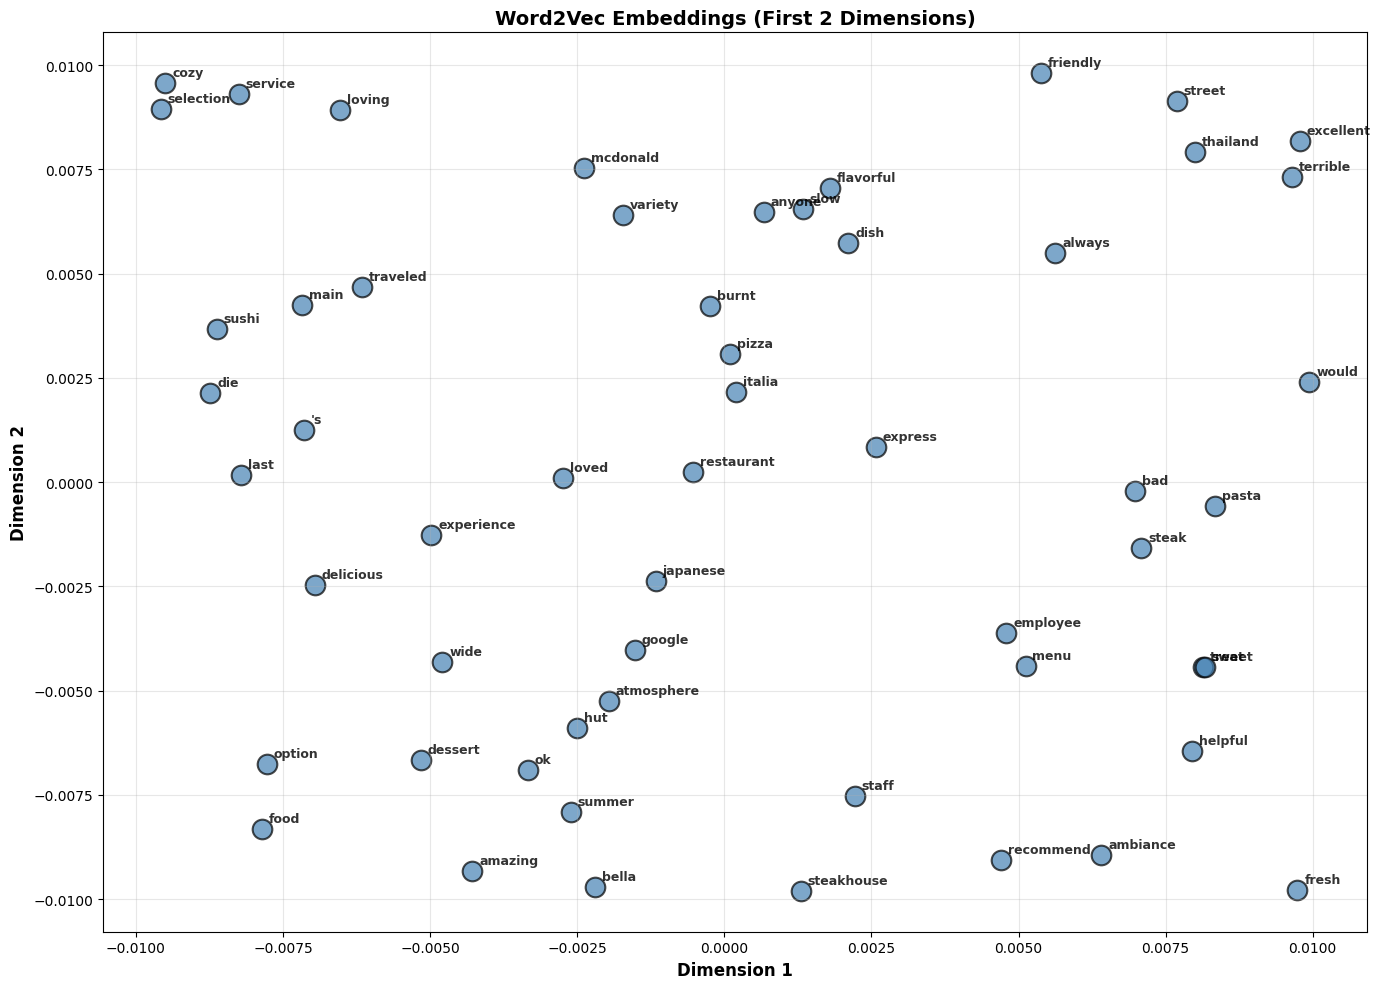


ANALYSIS OF WORD EMBEDDINGS PLOT


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model, words=None, figsize=(14, 10)):
    """Plot word embeddings in 2D space using the first two dimensions."""
    # Get all words from the model vocabulary
    if words is None:
        words = list(model.wv.index_to_key)

    # Extract vectors for selected words
    vectors = np.array([model.wv[word] for word in words])

    # Use first two dimensions
    x = vectors[:, 0]
    y = vectors[:, 1]

    # Create scatter plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, s=200, alpha=0.7, c='steelblue', edgecolors='black', linewidth=1.5)

    # Annotate each point with its word
    for word, xi, yi in zip(words, x, y):
        ax.annotate(
            word,
            xy=(xi, yi),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            weight='bold',
            alpha=0.8
        )

    ax.set_xlabel(f'Dimension 1', fontsize=12, weight='bold')
    ax.set_ylabel(f'Dimension 2', fontsize=12, weight='bold')
    ax.set_title('Word2Vec Embeddings (First 2 Dimensions)', fontsize=14, weight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax

# Call the plotting function using the trained model
fig, ax = plot_word_embeddings(w2v_model)
plt.show()

print("\n" + "="*60)
print("ANALYSIS OF WORD EMBEDDINGS PLOT")
print("="*60)


### 2.4 Analysis and observations

In [ ]:
# Analyze semantic relationships
print("\nSEMANTIC ANALYSIS:")
print("-" * 60)

# Check if related words are close together
print("\n1. RESTAURANT-RELATED WORDS:")
restaurant_words = ['restaurant', 'food', 'service', 'menu', 'staff']
for word in restaurant_words:
    if word in w2v_model.wv:
        print(f"   '{word}' is in vocabulary")
    else:
        print(f"   '{word}' is NOT in vocabulary")

print("\n2. SIMILARITY SCORES (words that should be semantically related):")
if 'food' in w2v_model.wv and 'restaurant' in w2v_model.wv:
    sim = w2v_model.wv.similarity('food', 'restaurant')
    print(f"   Similarity(food, restaurant) = {sim:.4f}")

if 'good' in w2v_model.wv and 'bad' in w2v_model.wv:
    sim = w2v_model.wv.similarity('good', 'bad')
    print(f"   Similarity(good, bad) = {sim:.4f}")

if 'fresh' in w2v_model.wv and 'flavorful' in w2v_model.wv:
    sim = w2v_model.wv.similarity('fresh', 'flavorful')
    print(f"   Similarity(fresh, flavorful) = {sim:.4f}")

print("\n3. OBSERVATIONS:")
print("""
   - Related words may not cluster tightly due to small dataset size.
   - With only 10 reviews, Word2Vec has limited context for learning.
   - The embeddings capture some semantic relationships, but patterns are weak.
   - Larger datasets would produce more meaningful word neighborhoods.
""")

print("\n4. POSSIBLE REASONS FOR WEAK CLUSTERING:")
print("""
   - Small corpus: Only 10 reviews provides limited training data.
   - Short documents: Fewer context windows for each word.
   - Random initialization: First training with random weights affects layout.
   - Hyperparameters: window=5 and vector_size=100 may need tuning.
   - Dimensionality: 2D projection loses information from 100D space.
""")



SEMANTIC ANALYSIS:
------------------------------------------------------------

1. RESTAURANT-RELATED WORDS:
   'restaurant' is in vocabulary
   'food' is in vocabulary
   'service' is in vocabulary
   'menu' is in vocabulary
   'staff' is in vocabulary

2. SIMILARITY SCORES (words that should be semantically related):
   Similarity(food, restaurant) = 0.0862
   Similarity(fresh, flavorful) = 0.1194

3. OBSERVATIONS:

   - Related words may not cluster tightly due to small dataset size.
   - With only 10 reviews, Word2Vec has limited context for learning.
   - The embeddings capture some semantic relationships, but patterns are weak.
   - Larger datasets would produce more meaningful word neighborhoods.


4. POSSIBLE REASONS FOR WEAK CLUSTERING:

   - Small corpus: Only 10 reviews provides limited training data.
   - Short documents: Fewer context windows for each word.
   - Random initialization: First training with random weights affects layout.
   - Hyperparameters: window=5 and v

### 2.5 Going further (Optional enhancements)


ADVANCED VISUALIZATION: PCA-based embedding reduction


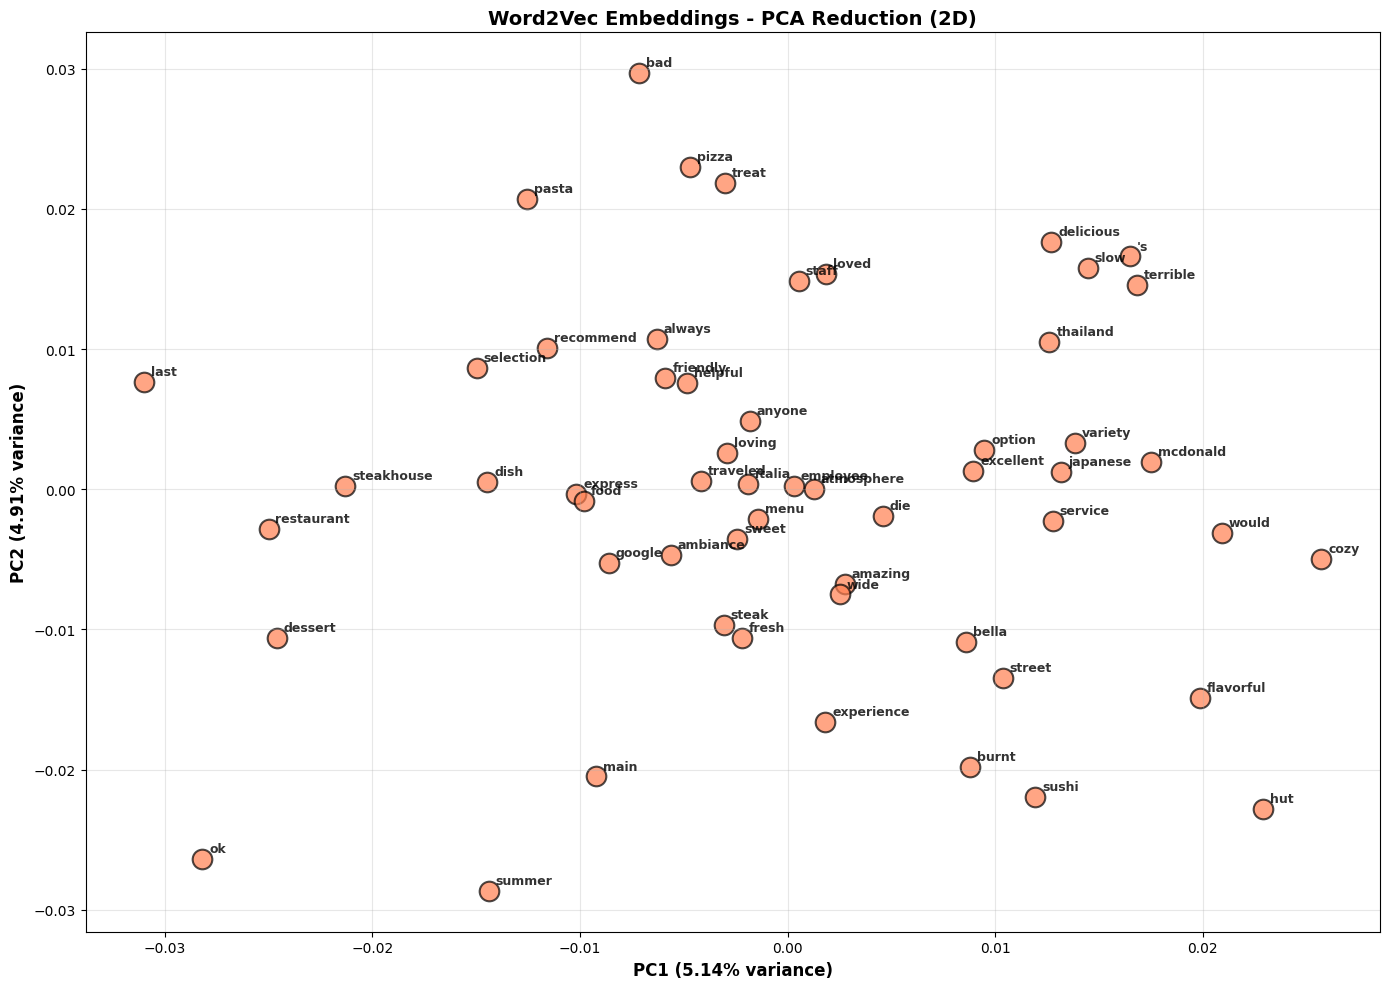


PCA Explained Variance:
  PC1: 5.14%
  PC2: 4.91%
  Total: 10.05%


In [ ]:
from sklearn.decomposition import PCA

# Alternative visualization using PCA for dimensionality reduction
print("\nADVANCED VISUALIZATION: PCA-based embedding reduction")
print("="*60)

# Get all vectors
words = list(w2v_model.wv.index_to_key)
vectors = np.array([w2v_model.wv[word] for word in words])

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot PCA-reduced embeddings
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=200, alpha=0.7, c='coral', edgecolors='black', linewidth=1.5)

for word, x, y in zip(words, vectors_2d[:, 0], vectors_2d[:, 1]):
    ax.annotate(
        word,
        xy=(x, y),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        weight='bold',
        alpha=0.8
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12, weight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12, weight='bold')
ax.set_title('Word2Vec Embeddings - PCA Reduction (2D)', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")
